---
title: "Exploratory Data Analysis"
format:
    html: 
        code-fold: false
---

# Introduction and Motivation

### 1. The Analytical Goal: The "Physics Gap"
Standard physical models dictate a cubic relationship between wind speed and power ($P \propto V^3$), theoretically forming a clean **Sigmoid Curve (S-Curve)**. However, our primary goal in this EDA is to challenge this theoretical assumption against real-world data. We aim to identify the **"Physics Gap"**—the discrepancy between theoretical expectations and actual grid behavior caused by turbulence, geographic complexity, and measurement proxies.

### 2. Key Hypotheses
Before diving into modeling, we use EDA to test two fundamental hypotheses that will guide our feature engineering:
* **Hypothesis 1 (The Cloud Effect):** Due to the distance between weather stations and wind farms, the Wind-Power relationship will not be a clean line but a high-variance "cloud," indicating the need for non-linear modeling.
* **Hypothesis 2 (The Volatility Trigger):** Hazardous "Ramp Events" are not driven solely by high wind speeds, but by high **Wind Volatility**. We expect to see a statistically significant difference in volatility distributions between stable and ramping states.

### 3. Analysis Roadmap
To validate these hypotheses, we will perform:
1.  **Temporal Analysis:** Visualizing the raw time series to identify the frequency and magnitude of ramp events.
2.  **Bivariate Analysis (The S-Curve):** Plotting Wind Speed vs. Power Output to visualize the variance and linearity (or lack thereof).
3.  **Distributional Analysis:** Comparing the statistical distributions of key features (Speed, Volatility) across "Stable" and "Ramp" classes to assess their predictive power.

# overview of methods

### 1. Data Preprocessing and Feature Engineering

Before analysis, we transform the raw time-series data to extract physically relevant signals:

* **Feature Aggregation:** We compute `Avg_Wind_Speed` by averaging readings from multiple airport sensors to create a robust proxy for regional wind conditions.
* **Volatility Modeling:** We construct a `Wind_Volatility` feature using a rolling 12-period standard deviation of wind speed to capture atmospheric turbulence.
* **Target Definition:** We derive the `Ramp_Type` classification (Stable, Up-Ramp, Down-Ramp) by calculating the discrete difference in `Power_MW` and applying a threshold-based logic.

### 2. Univariate Analysis

We examine variables in isolation to understand their fundamental properties:

* **Numerical Distributions:** We utilize summary statistics (mean, median, std) and histograms to assess the central tendency and spread of features like Wind Speed and Power.
* **Categorical Composition:** We use frequency counts to visualize the distribution of `Ramp_Type`, specifically to quantify the degree of class imbalance between stable operations and rare ramp events.

### 3. Bivariate and Multivariate Analysis

We explore relationships between variables to identify potential predictors:

* **Correlation Analysis:** We compute a Pearson correlation matrix, visualized via heatmaps, to quantify linear relationships between meteorological inputs and power output.
* **Feature Pairings:** We employ pair plots to visualize the multi-dimensional structure of the data and check for separability between classes.
* **Interaction Analysis:** We use cross-tabulations and stacked bar charts/heatmaps to analyze how the frequency of ramp events changes across different discretized wind speed levels.

### 4. Distributional Assessment and Transformation

We evaluate the statistical properties required for downstream modeling:

* **Normality Checks:** We calculate **Skewness** and **Kurtosis** to quantify the asymmetry and tail-heaviness of the data.
* **Transformation & Scaling:** We demonstrate the impact of **Log Transformation** on skewed variables (like Power Output) and compare normalization techniques (Min-Max Scaling vs. Z-Score Standardization) to prepare data for algorithms sensitive to feature magnitude.

### 5. Statistical Hypothesis Testing

Finally, we apply formal statistical tests to validate visual observations:

* **T-Tests:** We perform independent T-tests to determine if there is a statistically significant difference in `Wind_Volatility` between stable states and ramp events.
* **Chi-Square Tests:** We conduct Chi-Square tests of independence to assess the relationship between categorical wind levels and the occurrence of ramp events.

# Code 

Data Loaded. Shape: (388665, 10)
Ramp Threshold (95th percentile): 44.40 MW
Ramp Event Counts:
 Ramp_Type_Label
Stable       369231
Up-Ramp       10459
Down-Ramp      8975
Name: count, dtype: int64


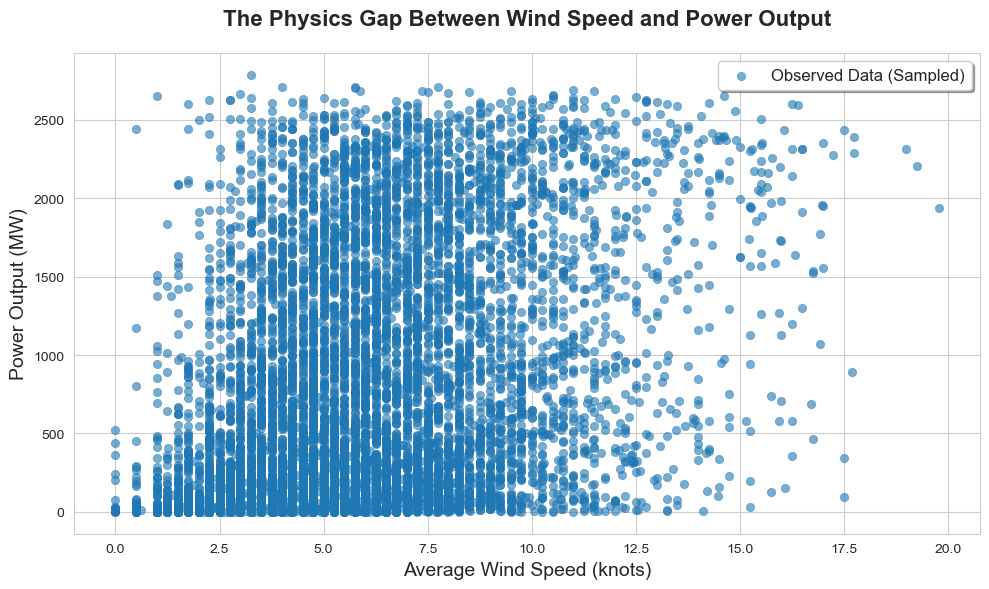

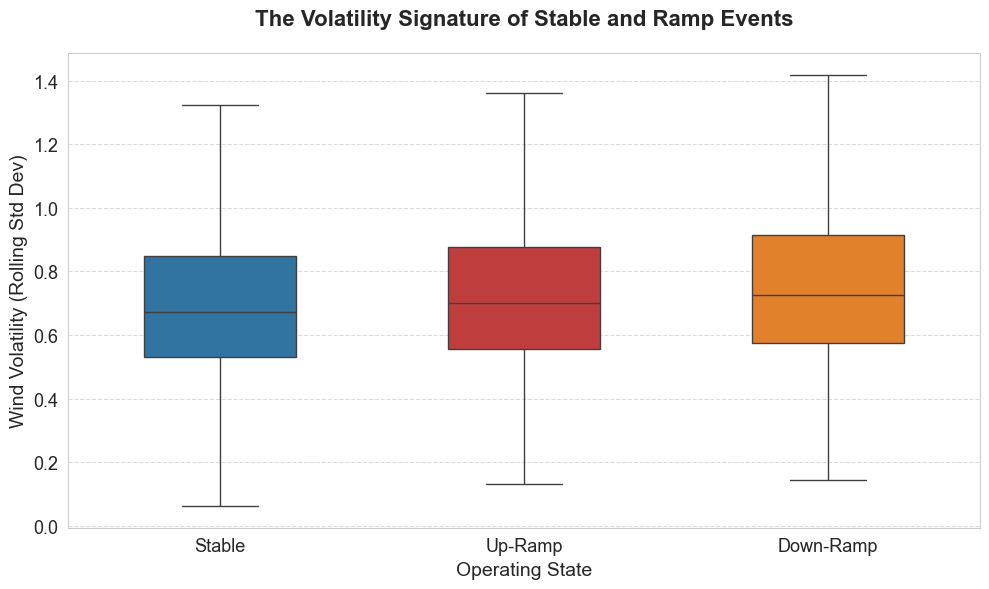


--- 1. Univariate Analysis ---
Numerical Summary:
                       mean         50%         std       min         max
Avg_Wind_Speed     5.870528    5.500000    2.802192  0.000000    24.62500
Wind_Volatility    0.713524    0.675252    0.257621  0.061391     3.49775
Power_MW         722.472696  391.000000  760.766574  0.000000  2833.50000


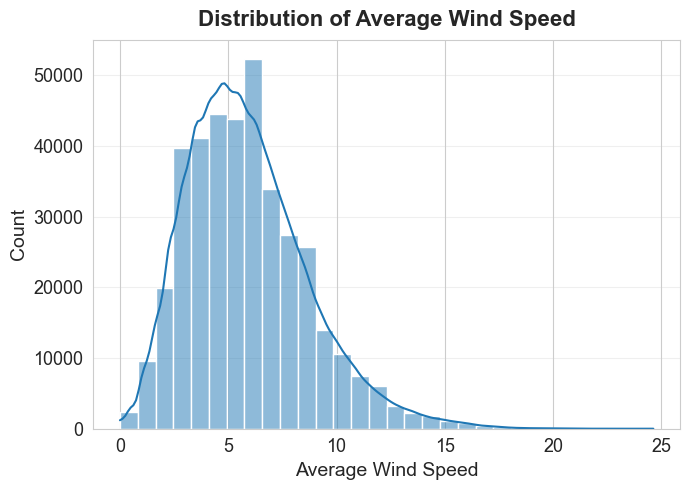

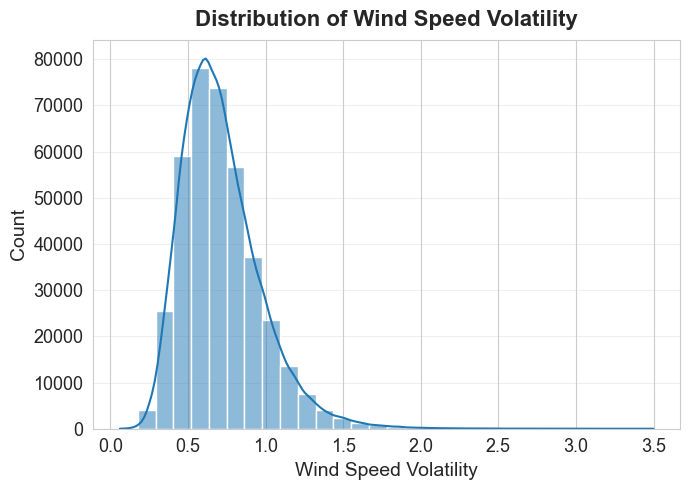

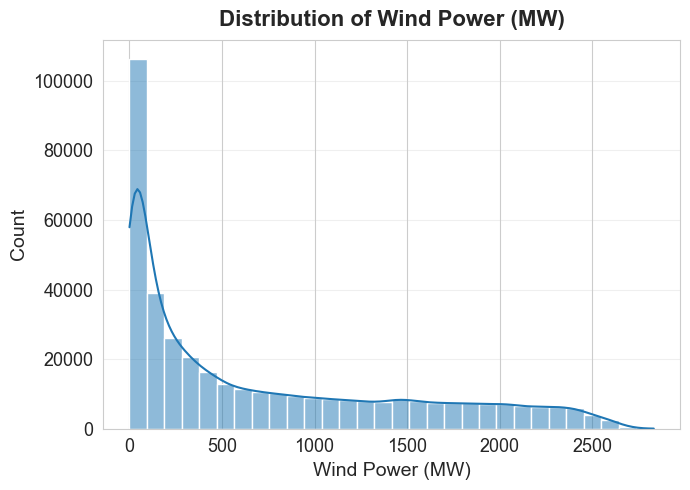


--- 2. Bivariate & Multivariate Analysis ---


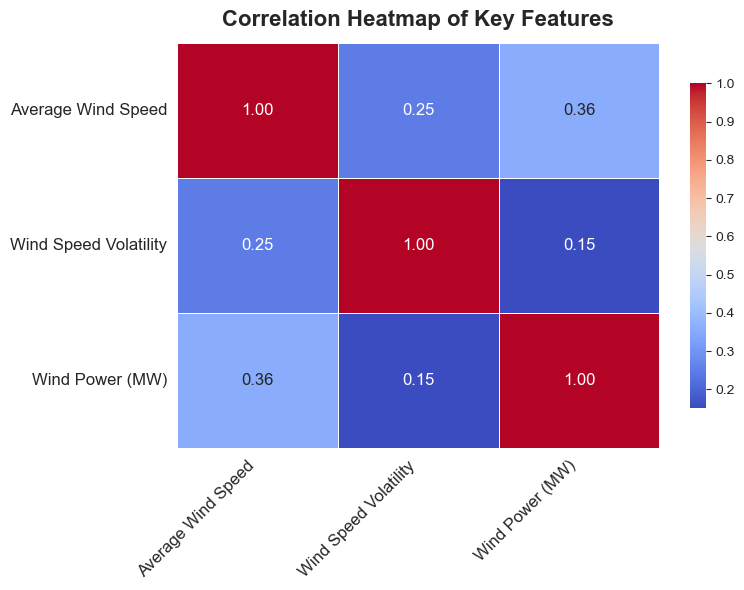

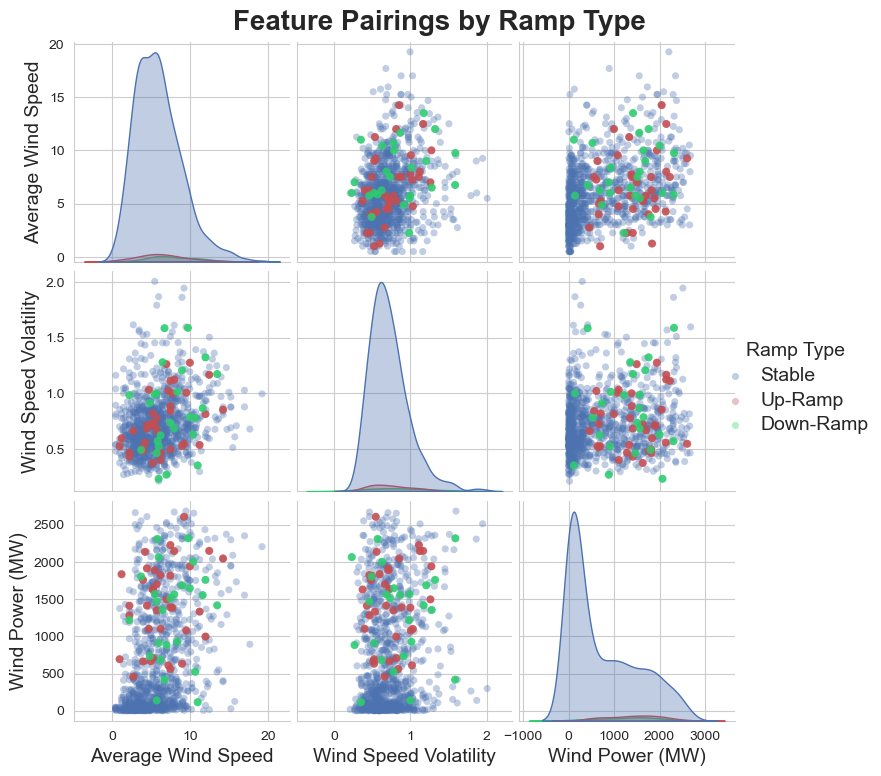

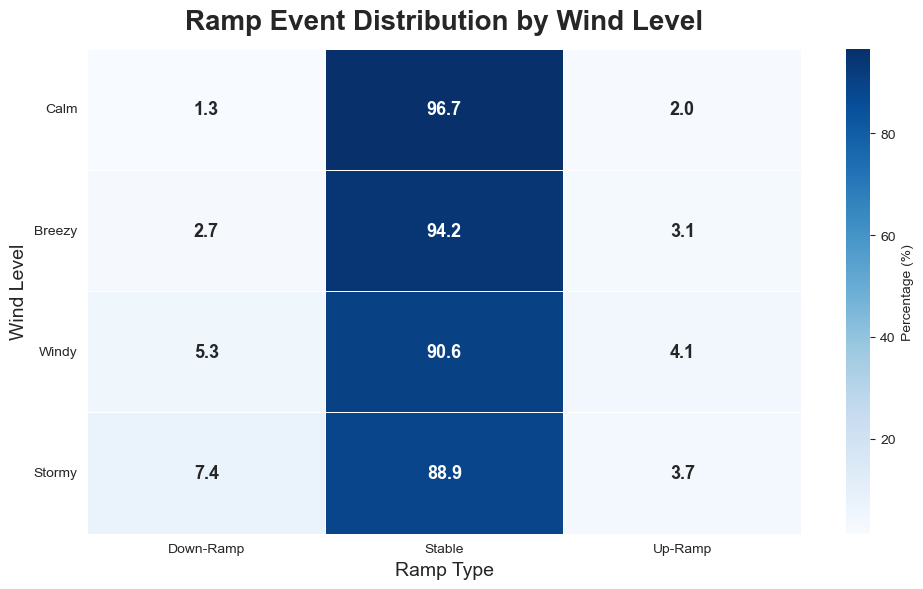


--- 3. Distribution & Normalization ---


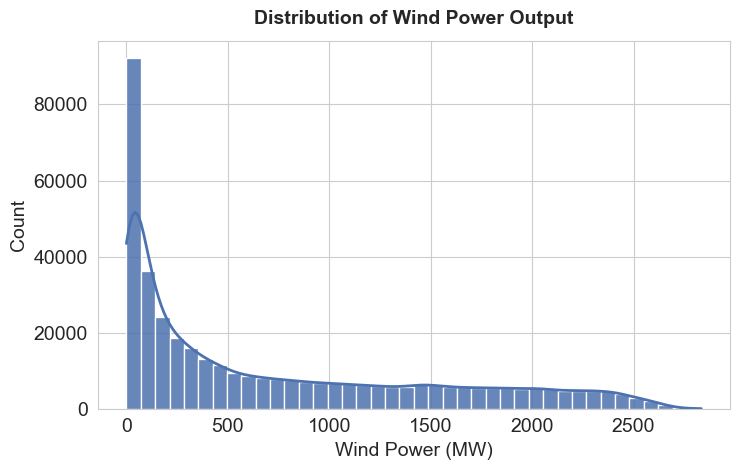

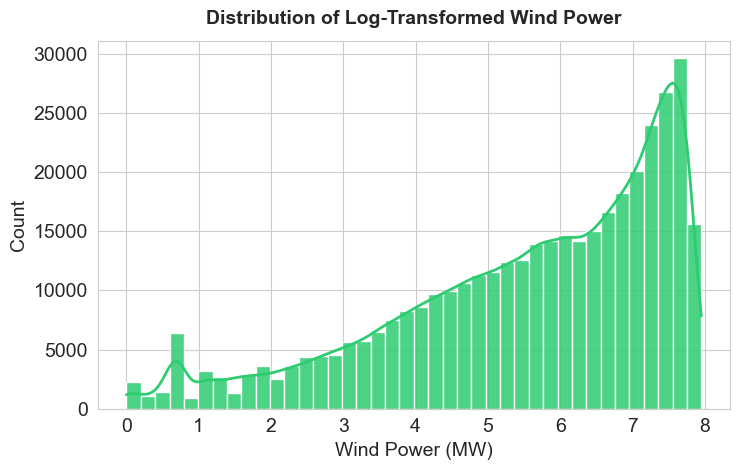

Original Wind Range: 0.00 - 24.62
Min-Max Scaled Range: 0.00 - 1.00
Z-Score Scaled Mean: 0.00, Std: 1.00

--- 4. Statistical Tests ---
T-Test (Volatility): T-stat=-22.4021, P-value=6.9814e-110
>> Result: Significant difference detected.

Chi-Square Test (Wind Level vs Ramp): Chi2=2943.1687, P-value=0.0000e+00


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# =====================================================
# 0. Data Preparation
# =====================================================
df = pd.read_csv("../../data/processed-data/BPA_Cleaned_Final_Robust.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.set_index('Timestamp').sort_index()

print("Data Loaded. Shape:", df.shape)

# Compute average wind speed across all wind sensors
wind_cols = [c for c in df.columns if 'sknt' in c]
df['Avg_Wind_Speed'] = df[wind_cols].mean(axis=1)

# Compute wind speed volatility (1-hour rolling standard deviation)
df['Wind_Volatility'] = df['Avg_Wind_Speed'].rolling(window=12).std()

# Compute power change between consecutive time steps
df['Power_Diff'] = df['Power_MW'].diff()

# Define ramp threshold using the 95th percentile of absolute power change
ramp_threshold = df['Power_Diff'].abs().quantile(0.95)

# Binary ramp indicator
df['Ramp_Type'] = (df['Power_Diff'].abs() > ramp_threshold).astype(int)

# Ramp direction classification
df['Ramp_Type_Label'] = df['Power_Diff'].apply(
    lambda x: 'Up-Ramp' if x > ramp_threshold 
    else ('Down-Ramp' if x < -ramp_threshold else 'Stable')
)

print(f"Ramp Threshold (95th percentile): {ramp_threshold:.2f} MW")
print("Ramp Event Counts:\n", df['Ramp_Type_Label'].value_counts())


features_num = ['Avg_Wind_Speed', 'Wind_Volatility', 'Power_MW']

categorical_cols = ['Ramp_Type_Label']


df_sample = df.sample(n=10000, random_state=42)
# Set Style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 2. Plot with Legend Label
sns.scatterplot(
    data=df_sample, 
    x='Avg_Wind_Speed', 
    y='Power_MW', 
    alpha=0.6,         
    color='#1f77b4', 
    edgecolor=None,
    label='Observed Data (Sampled)' 
)

# Titles and Labels
plt.title('The Physics Gap Between Wind Speed and Power Output', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Wind Speed (knots)', fontsize=14)
plt.ylabel('Power Output (MW)', fontsize=14)

# 3. Legend in Upper Right
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
import seaborn as sns

# Clean data: remove missing labels and reset index to prevent alignment errors
df_clean = df.dropna(subset=['Ramp_Type_Label']).copy().reset_index(drop=True)

# Define color palette for ramp types
my_palette = {
    "Stable": "#1f77b4",   # Blue
    "Up-Ramp": "#d62728",  # Red
    "Down-Ramp": "#ff7f0e" # Orange
}

# Initialize figure
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df_clean,
    x='Ramp_Type_Label',
    y='Wind_Volatility',
    palette=my_palette,
    showfliers=False,
    width=0.5,
    hue='Ramp_Type_Label'
)

# Set chart titles and labels
plt.title('The Volatility Signature of Stable and Ramp Events', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Operating State', fontsize=14)
plt.ylabel('Wind Volatility (Rolling Std Dev)', fontsize=14)

plt.xticks(fontsize=13)  
plt.yticks(fontsize=13)  

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optimize layout and display
plt.tight_layout()
plt.show()


# =====================================================
# 1. Univariate Analysis
# =====================================================
print("\n--- 1. Univariate Analysis ---")

# Numerical summary statistics
print("Numerical Summary:")
print(df[features_num].describe().T[['mean', '50%', 'std', 'min', 'max']])

def plot_feature_distributions(df, features, label_map=None, bins=30):
    """Plot histogram + KDE for numerical features."""

    TITLE_SIZE = 16
    LABEL_SIZE = 14
    TICK_SIZE  = 13
    COLOR = "#1f77b4"

    if label_map is None:
        label_map = {c: c.replace("_", " ") for c in features}

    for col in features:
        pretty = label_map.get(col, col.replace("_", " "))

        plt.figure(figsize=(7, 5))
        sns.histplot(df[col].dropna(), bins=bins, kde=True, color=COLOR)

        plt.title(f"Distribution of {pretty}", fontsize=TITLE_SIZE, fontweight="bold", pad=10)
        plt.xlabel(pretty, fontsize=LABEL_SIZE)
        plt.ylabel("Count", fontsize=LABEL_SIZE)

        plt.xticks(fontsize=TICK_SIZE)
        plt.yticks(fontsize=TICK_SIZE)
        plt.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()


features = ["Avg_Wind_Speed", "Wind_Volatility", "Power_MW"]

label_map = {
    "Avg_Wind_Speed": "Average Wind Speed",
    "Wind_Volatility": "Wind Speed Volatility",
    "Power_MW": "Wind Power (MW)"
}

plot_feature_distributions(df, features, label_map=label_map, bins=30)

# =====================================================
# 2. Bivariate & Multivariate Analysis
# =====================================================
print("\n--- 2. Bivariate & Multivariate Analysis ---")

# Correlation matrix and heatmap
corr_matrix = df[features_num].corr()
pretty_labels = [label_map.get(c, c.replace("_", " ")) for c in corr_matrix.columns]

plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 12}
)

ax.set_xticklabels(pretty_labels, rotation=45, ha="right", fontsize=12)
ax.set_yticklabels(pretty_labels, rotation=0, fontsize=12)

plt.title(
    "Correlation Heatmap of Key Features",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.tight_layout()
plt.show()

# Pairwise feature relationships
plot_sample = df.sample(n=1000, random_state=42)

pretty_labels = {
    "Avg_Wind_Speed": "Average Wind Speed",
    "Wind_Volatility": "Wind Speed Volatility",
    "Power_MW": "Wind Power (MW)"
}

plot_sample_renamed = plot_sample.rename(columns=pretty_labels)
x_vars = list(pretty_labels.values())

g = sns.pairplot(
    plot_sample_renamed,
    vars=x_vars,
    hue="Ramp_Type_Label",
    palette=["#4C72B0", "#C44E52", "#2ECC71"],
    diag_kind="kde",
    plot_kws={
        "alpha": 0.35,
        "s": 26,
        "edgecolor": "none"
    },
    diag_kws={
        "fill": True,
        "alpha": 0.35
    }
)

g.fig.suptitle(
    "Feature Pairings by Ramp Type",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=14)
        ax.set_ylabel(ax.get_ylabel(), fontsize=14)

# Overlay ramp events for emphasis
ramp_df = plot_sample_renamed[
    plot_sample_renamed["Ramp_Type_Label"].isin(["Up-Ramp", "Down-Ramp"])
].copy()

color_map = {
    "Up-Ramp": "#C44E52",
    "Down-Ramp": "#2ECC71"
}

legend = g._legend
legend.set_title("Ramp Type", prop={"size": 14})
for text in legend.get_texts():
    text.set_fontsize(14)

for i, y in enumerate(x_vars):
    for j, x in enumerate(x_vars):
        ax = g.axes[i, j]
        if i == j:
            continue

        for cls in ["Up-Ramp", "Down-Ramp"]:
            sub = ramp_df[ramp_df["Ramp_Type_Label"] == cls]
            ax.scatter(
                sub[x], sub[y],
                s=34,
                alpha=0.85,
                color=color_map[cls],
                edgecolors="none",
                zorder=10
            )

plt.show()

# Categorical interaction via crosstab
plt.figure(figsize=(10, 6))

df['Wind_Level'] = pd.cut(
    df['Avg_Wind_Speed'], 
    bins=[0, 5, 10, 15, 100], 
    labels=['Calm', 'Breezy', 'Windy', 'Stormy'],
    include_lowest=True  
)
ct = pd.crosstab(
    df['Wind_Level'],
    df['Ramp_Type_Label'],
    normalize='index'
) * 100

sns.heatmap(
    ct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={'label': 'Percentage (%)'},
    annot_kws={"size": 13, "weight": "bold"}
)

plt.title(
    "Ramp Event Distribution by Wind Level",
    fontsize=20,
    fontweight="bold",
    pad=14
)

plt.xlabel("Ramp Type", fontsize=14)
plt.ylabel("Wind Level", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# =====================================================
# 3. Distribution & Normalization
# =====================================================
print("\n--- 3. Distribution & Normalization ---")

plt.figure(figsize=(7.5, 4.8))

df['Log_Power_MW'] = np.log1p(df['Power_MW'])
sns.histplot(
    df['Power_MW'],
    bins=40,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    alpha=0.85,
    line_kws={"linewidth": 2}
)

plt.title(
    "Distribution of Wind Power Output",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.tick_params(axis='both', labelsize=14)
plt.xlabel("Wind Power (MW)", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7.5, 4.8))

sns.histplot(
    df['Log_Power_MW'],
    bins=40,
    kde=True,
    color="#2ECC71",
    edgecolor="white",
    alpha=0.85,
    line_kws={"linewidth": 2}
)

plt.title(
    "Distribution of Log-Transformed Wind Power",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.tick_params(axis='both', labelsize=14)
plt.xlabel("Wind Power (MW)", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.tight_layout()
plt.show()

# Normalization examples
scaler_mm = MinMaxScaler()
scaler_std = StandardScaler()
wind_mm = scaler_mm.fit_transform(df[['Avg_Wind_Speed']])
wind_std = scaler_std.fit_transform(df[['Avg_Wind_Speed']])
print(f"Original Wind Range: {df['Avg_Wind_Speed'].min():.2f} - {df['Avg_Wind_Speed'].max():.2f}")
print(f"Min-Max Scaled Range: {wind_mm.min():.2f} - {wind_mm.max():.2f}")
print(f"Z-Score Scaled Mean: {wind_std.mean():.2f}, Std: {wind_std.std():.2f}")
# =====================================================
# 4. Statistical Tests
# =====================================================
print("\n--- 4. Statistical Tests ---")
# T-test: volatility difference
group_stable = df[df['Ramp_Type'] == 0]['Wind_Volatility'].dropna()
group_ramp = df[df['Ramp_Type'] != 0]['Wind_Volatility'].dropna()
t_stat, p_val = stats.ttest_ind(group_stable, group_ramp, equal_var=False)
print(f"T-Test (Volatility): T-stat={t_stat:.4f}, P-value={p_val:.4e}")
if p_val < 0.05:
    print(">> Result: Significant difference detected.")
else:
    print(">> Result: No significant difference detected.")
# Chi-square test: wind level vs ramp occurrence
contingency_table = pd.crosstab(df['Wind_Level'], df['Ramp_Type_Label'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Test (Wind Level vs Ramp): Chi2={chi2:.4f}, P-value={p:.4e}")

# Summary and Interpretation of Results

### Structural Characteristics of the Dataset

* The BPA wind power dataset exhibits a severe class imbalance, with stable operations accounting for approximately 95% of all observations, while hazardous ramp events are extremely rare.
* This imbalance explains why standard models struggle to detect ramp events and justifies the use of an undersampling strategy, in which stable observations are selectively reduced to improve model learning.
* In addition, wind power output is highly right-skewed, but applying a log transformation successfully normalizes the distribution, making it suitable for downstream regression modeling.


### Statistical Drivers of Grid Instability

* Statistical testing shows that grid instability is driven primarily by wind volatility, rather than wind speed alone.
* An independent t-test reveals a statistically significant difference in volatility between stable operating periods and ramp events, confirming that ramp events are distinct physical phenomena rather than random noise.
* A chi-square test further confirms a strong dependency between specific wind levels and the occurrence of ramp events.

### Insights from Visualization and Pattern Discovery

* Annotated heatmaps reveal that the probability of ramp events increases sharply under high-volatility conditions, making rare events visible despite their low frequency.
* Scatter plot analysis shows substantial class overlap in feature space, indicating that simple linear decision boundaries are unlikely to separate ramp events effectively.
* These observed patterns motivate the use of non-linear models, such as Random Forest and Gradient Boosting, in the next stage of the project.


### Implications for Modeling Strategy

* The EDA demonstrates that wind volatility is a key predictor of grid instability and that ramp events require specialized handling due to their rarity.
* These findings directly inform our next steps: prioritizing volatility-based features and explicitly addressing class imbalance to build a robust early warning system.

